# Kiểm tra chất lượng dữ liệu & Sự tương đồng (Data Quality & Split Consistency)

Notebook này thực hiện các bước kiểm tra cuối cùng để đảm bảo dataset sạch và sẵn sàng cho huấn luyện:
1. So sánh phân phối các lớp giữa các tập Train/Val/Test.
2. Phát hiện và xử lý ảnh trùng lặp (Duplicates).
3. Phân tích chất lượng ảnh (ảnh lỗi, ảnh mờ, outliers).

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from tqdm import tqdm

# Thiet lap tham my
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

EMOTIONS_MAP = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}
DATA_DIR = "../../data/fer_data/"

print("Dang tai du lieu va mapping...")
df_train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
df_val = pd.read_csv(os.path.join(DATA_DIR, "val.csv"))
df_test = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

dfs = {'Train': df_train, 'Val': df_val, 'Test': df_test}

# Fallback mapping de tranh NameError o cac cell sau.
# Neu dataset co cot path, co the bo sung mapping chi tiet hon.
pixel_to_path = {}

Dang tai du lieu va mapping...


## 1. Kiểm tra sự tương đồng giữa các tập Split
Chúng ta cần đảm bảo tỷ lệ các lớp trong tập Val và Test tương đồng với tập Train để tránh hiện tượng **Data Shift**.

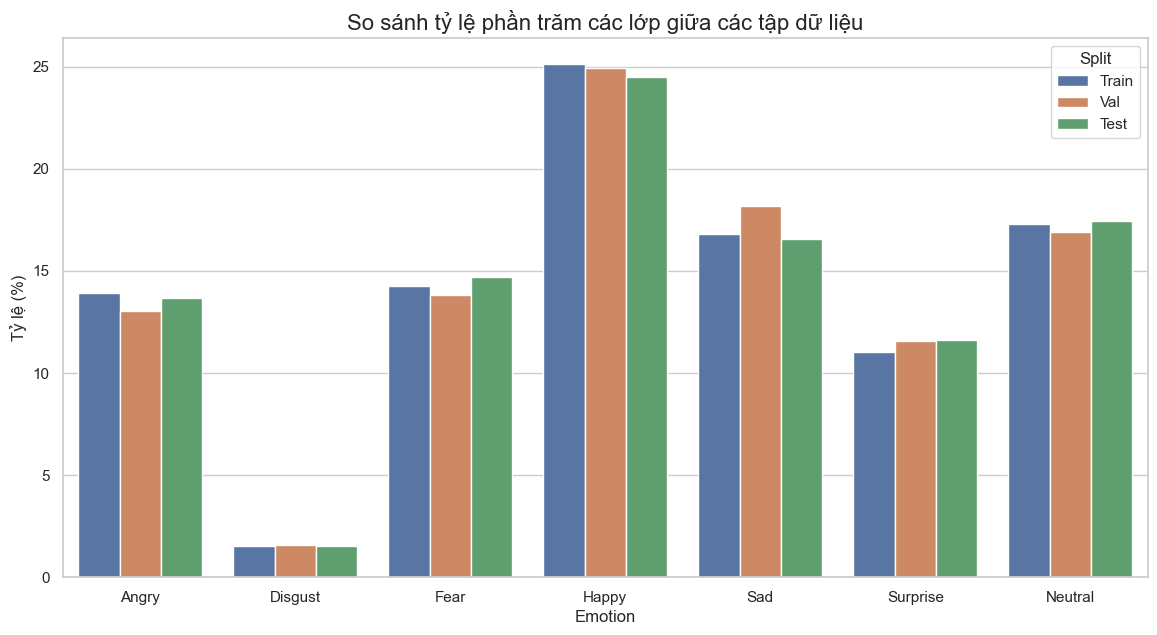

In [15]:
dist_data = []
for name, df in dfs.items():
    counts = df['emotion'].value_counts(normalize=True).sort_index() * 100
    for emotion_idx, percentage in counts.items():
        dist_data.append({
            'Split': name,
            'Emotion': EMOTIONS_MAP[emotion_idx],
            'Percentage': percentage
        })

df_dist = pd.DataFrame(dist_data)

plt.figure(figsize=(14, 7))
sns.barplot(data=df_dist, x='Emotion', y='Percentage', hue='Split')
plt.title("So sánh tỷ lệ phần trăm các lớp giữa các tập dữ liệu", fontsize=16)
plt.ylabel("Tỷ lệ (%)")
plt.show()

## 2. Phát hiện ảnh trùng lặp (Duplicates)
Ảnh trùng lặp có thể gây ra overfitting hoặc rò rỉ dữ liệu (Data Leakage) nếu cùng một ảnh xuất hiện ở cả tập Train và Test.

In [16]:
print("--- Kiem tra trung lap trong noi bo tap du lieu ---")
for name, df in dfs.items():
    duplicated_pixels = df.loc[df.duplicated(subset=['pixels']), 'pixels'].unique()
    num_dupes = int(df.duplicated(subset=['pixels']).sum())
    print(f"{name}: {num_dupes} anh trung lap.")

    if len(duplicated_pixels) > 0:
        print(f"Vi du mot so anh trung lap trong {name}:")
        for p in list(duplicated_pixels)[:3]:
            row_ids = df.index[df['pixels'] == p].tolist()
            print(f"  - Pixel hash={hash(p)} xuat hien tai row indices: {row_ids[:8]}")
            if 'folder_pixel_index' in globals() and isinstance(folder_pixel_index, dict):
                folder_paths = folder_pixel_index.get(p, [])
                if folder_paths:
                    print(f"    File paths (toi da 3): {folder_paths[:3]}")

print("\n--- Kiem tra ro ri du lieu giua Train va Val/Test ---")
train_pixels = set(df_train['pixels'])
val_pixels = set(df_val['pixels'])
test_pixels = set(df_test['pixels'])

overlap_val_pixels = train_pixels.intersection(val_pixels)
overlap_test_pixels = train_pixels.intersection(test_pixels)

print(f"So luong anh Train xuat hien trong Val: {len(overlap_val_pixels)}")
if len(overlap_val_pixels) > 0:
    print("Vi du anh ro ri (Train <-> Val):")
    for p in list(overlap_val_pixels)[:3]:
        train_rows = df_train.index[df_train['pixels'] == p].tolist()
        val_rows = df_val.index[df_val['pixels'] == p].tolist()
        print(f"  - hash={hash(p)} | Train rows: {train_rows[:5]} | Val rows: {val_rows[:5]}")
        if 'folder_pixel_index' in globals() and isinstance(folder_pixel_index, dict):
            folder_paths = folder_pixel_index.get(p, [])
            if folder_paths:
                print(f"    File paths (toi da 3): {folder_paths[:3]}")

print(f"So luong anh Train xuat hien trong Test: {len(overlap_test_pixels)}")
if len(overlap_test_pixels) > 0:
    print("Vi du anh ro ri (Train <-> Test):")
    for p in list(overlap_test_pixels)[:3]:
        train_rows = df_train.index[df_train['pixels'] == p].tolist()
        test_rows = df_test.index[df_test['pixels'] == p].tolist()
        print(f"  - hash={hash(p)} | Train rows: {train_rows[:5]} | Test rows: {test_rows[:5]}")
        if 'folder_pixel_index' in globals() and isinstance(folder_pixel_index, dict):
            folder_paths = folder_pixel_index.get(p, [])
            if folder_paths:
                print(f"    File paths (toi da 3): {folder_paths[:3]}")

if 'folder_pixel_index' not in globals() or not folder_pixel_index:
    print("\nGoi build_folder_index() o Cell 10 neu ban muon in kem duong dan file anh trong folder.")

--- Kiem tra trung lap trong noi bo tap du lieu ---
Train: 1236 anh trung lap.
Vi du mot so anh trung lap trong Train:
  - Pixel hash=-7123885150190555655 xuat hien tai row indices: [304, 675]
  - Pixel hash=-2515876588350939432 xuat hien tai row indices: [712, 718]
  - Pixel hash=-3839996961237341322 xuat hien tai row indices: [909, 1145]
Val: 26 anh trung lap.
Vi du mot so anh trung lap trong Val:
  - Pixel hash=-324398308155204822 xuat hien tai row indices: [397, 696]
  - Pixel hash=4476517462406594086 xuat hien tai row indices: [409, 806]
  - Pixel hash=-568021727377077108 xuat hien tai row indices: [712, 953]
Test: 17 anh trung lap.
Vi du mot so anh trung lap trong Test:
  - Pixel hash=4163723681475134295 xuat hien tai row indices: [433, 522]
  - Pixel hash=8852468403618552103 xuat hien tai row indices: [1047, 1271]
  - Pixel hash=5223231235825668791 xuat hien tai row indices: [520, 1445]

--- Kiem tra ro ri du lieu giua Train va Val/Test ---
So luong anh Train xuat hien trong Val

### 2.1 Trực quan hóa rò rỉ dữ liệu (Visualizing Data Leakage)
Hãy xem thử một vài ví dụ về các ảnh xuất hiện ở cả tập **Train** và tập **Val**.

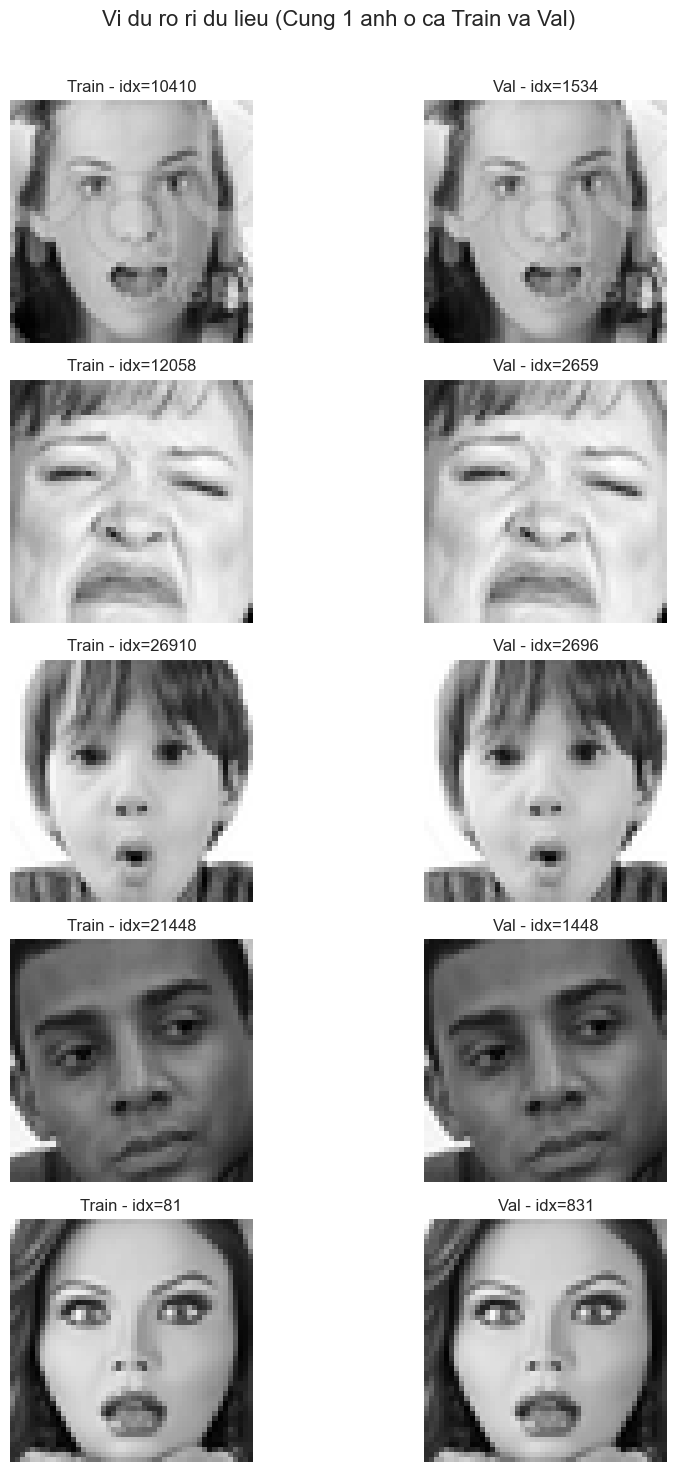

In [17]:
# Tao lai cac tap pixel neu chua ton tai (cho phep chay cell doc lap).
if 'train_pixels' not in globals() or 'val_pixels' not in globals():
    train_pixels = set(df_train['pixels'])
    val_pixels = set(df_val['pixels'])

common_pixels = list(train_pixels.intersection(val_pixels))[:5]

if len(common_pixels) > 0:
    fig, axes = plt.subplots(len(common_pixels), 2, figsize=(10, 3 * len(common_pixels)))
    fig.suptitle("Vi du ro ri du lieu (Cung 1 anh o ca Train va Val)", fontsize=16)

    # Khi chi co 1 dong, matplotlib tra ve mang 1 chieu -> reshape ve 2 chieu de index on dinh.
    if len(common_pixels) == 1:
        axes = np.array([axes])

    for i, pixels in enumerate(common_pixels):
        img = np.array(pixels.split(), dtype='int').reshape(48, 48)

        # Lay index dau tien cua anh trung trong moi split de hien thi de debug.
        train_idx = df_train.index[df_train['pixels'] == pixels].tolist()
        val_idx = df_val.index[df_val['pixels'] == pixels].tolist()
        train_label = f"idx={train_idx[0]}" if train_idx else "idx=N/A"
        val_label = f"idx={val_idx[0]}" if val_idx else "idx=N/A"

        axes[i, 0].imshow(img, cmap='gray')
        axes[i, 0].set_title(f"Train - {train_label}")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(img, cmap='gray')
        axes[i, 1].set_title(f"Val - {val_label}")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()
else:
    print("Khong co ro ri du lieu giua Train va Val.")

## 2.2 Tra cuu anh theo folder <-> train/val/test
Cell nay giup ban tra cuu 2 chieu:
1. Tu file anh trong folder, xac dinh no thuoc split nao trong CSV (train/val/test).
2. Tu dong trong CSV, tim cac file anh tuong ung trong folder (neu co).

Luu y: Neu anh trong folder khong trung dung pixel voi CSV (do resize/nen/JPEG), ket qua co the khong match.

In [18]:
from pathlib import Path
from PIL import Image
import re
import heapq

# Folder anh hien tai
IMAGE_ROOT = Path(r"D:\HocTap\Phân tích  và xử lý ảnh\sgu-2026-facial-expression-recognition\data\fer-2013_image")

def set_image_root(new_root):
    """Cap nhat folder anh de index/tra cuu."""
    global IMAGE_ROOT, folder_pixel_index
    IMAGE_ROOT = Path(new_root)
    folder_pixel_index = {}
    print(f"IMAGE_ROOT moi: {IMAGE_ROOT.resolve()}")

def image_to_pixel_string(image_path):
    img = Image.open(image_path).convert("L")
    arr = np.array(img, dtype=np.uint8)
    if arr.shape != (48, 48):
        raise ValueError(f"Anh {image_path} co size {arr.shape}, can (48, 48).")
    return " ".join(arr.flatten().astype(str))

def build_split_index():
    idx = {}
    for split_name, split_df in [("train", df_train), ("val", df_val), ("test", df_test)]:
        for row_idx, row in split_df[['emotion', 'pixels']].iterrows():
            idx.setdefault(row['pixels'], []).append({
                'split': split_name,
                'row_idx': int(row_idx),
                'emotion': int(row['emotion'])
            })
    return idx

pixel_split_index = build_split_index()
print(f"Da index {len(pixel_split_index):,} pixel strings tu train/val/test.")

folder_pixel_index = {}

def build_folder_index(max_files=None):
    """Index pixel -> danh sach file anh trong folder."""
    image_files = [
        p for p in IMAGE_ROOT.rglob('*')
        if p.suffix.lower() in {'.png', '.jpg', '.jpeg', '.bmp'}
    ]
    if max_files is not None:
        image_files = image_files[:max_files]

    local_index = {}
    for p in tqdm(image_files, desc=f'Indexing image folder: {IMAGE_ROOT.name}'):
        try:
            px = image_to_pixel_string(p)
            local_index.setdefault(px, []).append(str(p))
        except Exception:
            continue

    global folder_pixel_index
    folder_pixel_index = local_index
    print(f"Da index {len(image_files):,} files tu {IMAGE_ROOT}.")
    print(f"Match duoc {len(folder_pixel_index):,} unique pixel strings.")

def _get_df_by_split(split):
    split = split.lower()
    split_df_map = {'train': df_train, 'val': df_val, 'test': df_test}
    if split not in split_df_map:
        raise ValueError("split phai la train/val/test")
    return split_df_map[split]

def _search_filename_by_index(row_idx, max_results=10):
    idx_str = str(int(row_idx))
    hits = []
    for p in IMAGE_ROOT.rglob('*'):
        if p.suffix.lower() not in {'.png', '.jpg', '.jpeg', '.bmp'}:
            continue
        nums = re.findall(r'\d+', p.stem)
        if idx_str in nums:
            hits.append(str(p))
            if len(hits) >= max_results:
                break
    return hits

def _target_image_from_csv(split, row_idx):
    split_df = _get_df_by_split(split)
    px = split_df.loc[int(row_idx), 'pixels']
    return np.array(px.split(), dtype=np.float32).reshape(48, 48), int(split_df.loc[int(row_idx), 'emotion'])

def _split_folder_for_search(split):
    # Folder anh chi co train/test; val duoc doi chieu trong folder test.
    split = split.lower()
    return 'test' if split in {'val', 'test'} else 'train'

def find_nearest_filenames_for_index(split, row_idx, top_k=5, only_same_emotion=True):
    """Tim ten file gan giong nhat theo MAE khi khong match pixel exact."""
    target_img, target_emotion = _target_image_from_csv(split, row_idx)
    search_root = IMAGE_ROOT / _split_folder_for_search(split)
    if not search_root.exists():
        return pd.DataFrame()

    emotion_name = EMOTIONS_MAP[target_emotion].lower()
    if only_same_emotion and (search_root / emotion_name).exists():
        files = [p for p in (search_root / emotion_name).rglob('*') if p.suffix.lower() in {'.png', '.jpg', '.jpeg', '.bmp'}]
    else:
        files = [p for p in search_root.rglob('*') if p.suffix.lower() in {'.png', '.jpg', '.jpeg', '.bmp'}]

    candidates = []
    for p in tqdm(files, desc=f'Approx matching {split}:{row_idx}'):
        try:
            arr = np.array(Image.open(p).convert('L'), dtype=np.float32)
            if arr.shape != (48, 48):
                continue
            mae = float(np.mean(np.abs(arr - target_img)))
            if len(candidates) < top_k:
                heapq.heappush(candidates, (-mae, str(p)))
            elif mae < -candidates[0][0]:
                heapq.heapreplace(candidates, (-mae, str(p)))
        except Exception:
            continue

    best = sorted([(-x[0], x[1]) for x in candidates], key=lambda t: t[0])
    df_best = pd.DataFrame(best, columns=['mae', 'file_path'])
    if not df_best.empty:
        df_best['file_name'] = df_best['file_path'].apply(lambda x: Path(x).name)
    return df_best

def show_filename_for_index(split, row_idx, auto_build_folder=True):
    """Tra ten file theo index: exact pixel -> fallback filename -> nearest match."""
    split_df = _get_df_by_split(split)
    px = split_df.loc[int(row_idx), 'pixels']

    if auto_build_folder and not folder_pixel_index:
        build_folder_index()

    exact_paths = folder_pixel_index.get(px, [])
    print(f"\n=== Query: {split} idx={int(row_idx)} ===")
    if exact_paths:
        print('Ten file match pixel (chinh xac):')
        for p in exact_paths[:10]:
            print(' -', Path(p).name)
        return

    name_hits = _search_filename_by_index(row_idx, max_results=10)
    if name_hits:
        print('Khong co match pixel. Ten file co chua index (fallback):')
        for p in name_hits:
            print(' -', Path(p).name)
    else:
        print('Khong co match exact/fallback theo ten. Dang tim file gan giong nhat...')

    approx = find_nearest_filenames_for_index(split, row_idx, top_k=5, only_same_emotion=True)
    if approx.empty:
        print('Khong tim thay file phu hop trong IMAGE_ROOT hien tai.')
    else:
        print('Top file gan giong nhat (theo MAE nho nhat):')
        display(approx[['mae', 'file_name', 'file_path']])

# Cach dung:
show_filename_for_index('train', 5223)
show_filename_for_index('val', 1523)

Da index 34,034 pixel strings tu train/val/test.


Indexing image folder: fer-2013_image: 100%|██████████| 35887/35887 [00:46<00:00, 771.01it/s] 


Da index 35,887 files tu D:\HocTap\Phân tích  và xử lý ảnh\sgu-2026-facial-expression-recognition\data\fer-2013_image.
Match duoc 34,034 unique pixel strings.

=== Query: train idx=5223 ===
Khong co match exact/fallback theo ten. Dang tim file gan giong nhat...


Approx matching train:5223: 100%|██████████| 4097/4097 [00:01<00:00, 2264.16it/s]

Top file gan giong nhat (theo MAE nho nhat):


,mae,file_name,file_path
0,1.412760,Training_48938052.jpg,D:\HocTap\Phân tích và xử lý ảnh\sgu-2026-fac...
1,37.021267,Training_57546448.jpg,D:\HocTap\Phân tích và xử lý ảnh\sgu-2026-fac...
2,38.703995,Training_37991512.jpg,D:\HocTap\Phân tích và xử lý ảnh\sgu-2026-fac...
3,38.782986,Training_94200554.jpg,D:\HocTap\Phân tích và xử lý ảnh\sgu-2026-fac...
4,38.876736,Training_80897919.jpg,D:\HocTap\Phân tích và xử lý ảnh\sgu-2026-fac...



=== Query: val idx=1523 ===
Khong co match exact/fallback theo ten. Dang tim file gan giong nhat...


Approx matching val:1523: 100%|██████████| 1024/1024 [00:00<00:00, 4228.37it/s]

Top file gan giong nhat (theo MAE nho nhat):


,mae,file_name,file_path
0,1.412760,PublicTest_21354785.jpg,D:\HocTap\Phân tích và xử lý ảnh\sgu-2026-fac...
1,39.674480,PrivateTest_16765445.jpg,D:\HocTap\Phân tích và xử lý ảnh\sgu-2026-fac...
2,40.717014,PublicTest_75242098.jpg,D:\HocTap\Phân tích và xử lý ảnh\sgu-2026-fac...
3,40.815105,PrivateTest_36996738.jpg,D:\HocTap\Phân tích và xử lý ảnh\sgu-2026-fac...
4,40.935329,PrivateTest_58212078.jpg,D:\HocTap\Phân tích và xử lý ảnh\sgu-2026-fac...


## 3. Phân tích chất lượng ảnh (Data Quality Check)
Chúng ta sẽ tìm các ảnh có vấn đề như: quá tối, quá sáng, hoặc bị lỗi (uniform color).

In [19]:
def analyze_quality(df):
    stats = []
    for p_str in tqdm(df['pixels'], desc="Analyzing quality"):
        arr = np.array(p_str.split(), dtype='float32')
        stats.append({
            'mean': np.mean(arr),
            'std': np.std(arr),
            'min': np.min(arr),
            'max': np.max(arr)
        })
    return pd.DataFrame(stats)

quality_metrics = analyze_quality(df_train)

# 1. Ảnh 'Chết' (Standard Deviation cực thấp - ảnh gần như một màu phẳng)
dead_images = quality_metrics[quality_metrics['std'] < 1.0]
print(f"Tìm thấy {len(dead_images)} ảnh có khả năng bị lỗi (uniform color).")

# 2. Ảnh quá tối (Mean cực thấp)
dark_images = quality_metrics[quality_metrics['mean'] < 20]
print(f"Tìm thấy {len(dark_images)} ảnh rất tối (mean < 20).")

# 3. Ảnh quá sáng (Mean cực cao)
bright_images = quality_metrics[quality_metrics['mean'] > 230]
print(f"Tìm thấy {len(bright_images)} ảnh rất sáng (mean > 230).")

Analyzing quality: 100%|██████████| 28709/28709 [00:08<00:00, 3577.69it/s]

Tìm thấy 12 ảnh có khả năng bị lỗi (uniform color).
Tìm thấy 19 ảnh rất tối (mean < 20).
Tìm thấy 23 ảnh rất sáng (mean > 230).


## 4. Trực quan hóa các ảnh 'Nghi ngờ' (Outliers)
Hiển thị một số ảnh có độ lệch chuẩn thấp nhất hoặc phân phối cực đoan để kiểm tra xem có phải mặt người không.

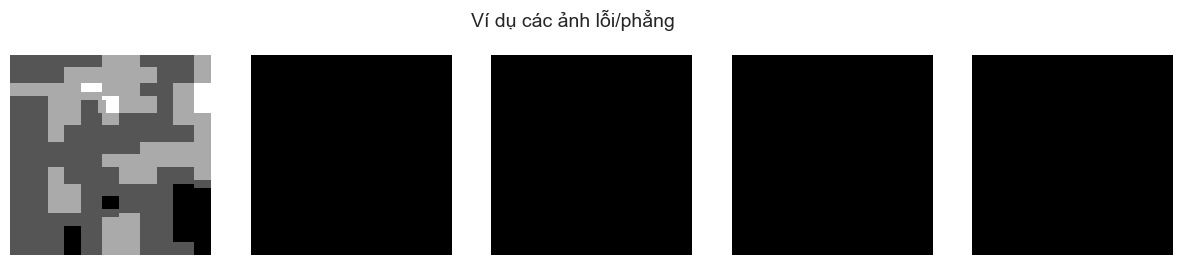

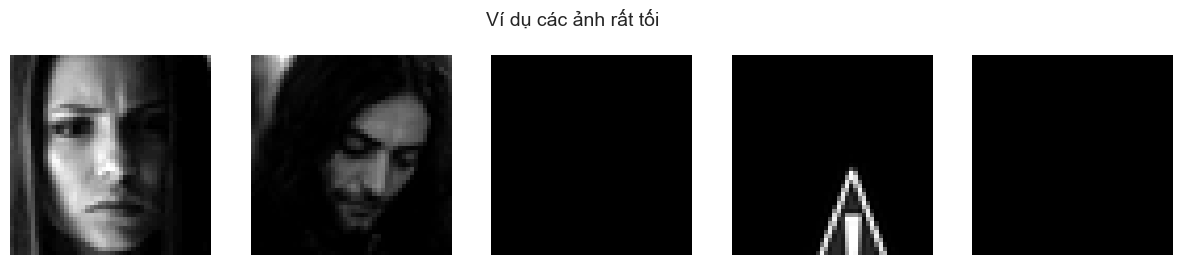

In [20]:
def show_outliers(df, indices, title):
    if len(indices) == 0:
        print(f"Không có outlier cho: {title}")
        return
    
    n = min(len(indices), 5)
    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    fig.suptitle(title, fontsize=14)
    
    if n == 1:
        axes = [axes]
        
    for i in range(n):
        img_str = df.iloc[indices[i]]['pixels']
        img = np.array(img_str.split(), dtype='int').reshape(48, 48)
        axes[i].imshow(img, cmap='gray')
        axes[i].axis('off')
    plt.show()

show_outliers(df_train, dead_images.index.tolist()[:10], "Ví dụ các ảnh lỗi/phẳng")
show_outliers(df_train, dark_images.index.tolist()[:10], "Ví dụ các ảnh rất tối")

## Tổng kết
- **Data Leakage**: Rò rỉ dữ liệu xảy ra khi cùng một ảnh (chuỗi pixel giống hệt nhau) xuất hiện ở cả tập huấn luyện và tập kiểm thử.
- **Hệ quả**: Mô hình có thể "học thuộc lòng" ảnh này và cho kết quả kiểm thử tốt một cách giả tạo.
- **Giải pháp**: Cần loại bỏ những ảnh trùng lặp này khỏi tập Train và chỉ giữ chúng trong Val/Test.